In [1]:
# Import modules
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
# Load data into a Pandas Dataframe
df = pd.read_csv("./data/966896_v1_ooi_pioneer_nes_ctd_and_water_sampling_data.csv")
df.head() # Print the first 5 rows of the DataFrame

,Cruise,Station,Target_Asset,Start_Latitude,Start_Longitude,Start_Time,Cast,Cast_Flag,Bottom_Depth_at_Start_Position,CTD_File,...,Discrete_pH_Replicate_Flag,Calculated_Alkalinity,Calculated_DIC,Calculated_pCO2,Calculated_pH,Calculated_CO2aq,Calculated_Bicarb,Calculated_CO3,Calculated_Omega_C,Calculated_Omega_A
0,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
def get_cruise_asset_data(df, cruise_id=None, target_asset=None, verbose=True):
    """
    Filters the dataframe by cruise_id and optionally by target_asset.

    Parameters:
        df (pd.DataFrame): The full dataset.
        cruise_id (str, optional): The Cruise ID to filter by.
        target_asset (str, optional): The Target Asset to filter by (must be valid for selected cruise).
        verbose (bool): If True, print available options at each step.

    Returns:
        pd.DataFrame: Filtered DataFrame based on provided cruise_id and target_asset.
    """
    # List available cruises
    available_cruises = df['Cruise'].unique()
    if verbose:
        print("Available Cruises:", available_cruises)

    if cruise_id is None:
        raise ValueError("Please provide a cruise_id from the available list.")

    cruise_df = df.query("Cruise == @cruise_id")

    if cruise_df.empty:
        raise ValueError(f"No data found for Cruise ID '{cruise_id}'.")

    # List available assets for the chosen cruise
    available_assets = cruise_df['Target_Asset'].unique()
    if verbose:
        print(f"Available Target Assets for cruise '{cruise_id}':", available_assets)

    if target_asset is not None:
        if target_asset not in available_assets:
            raise ValueError(f"'{target_asset}' is not a valid Target_Asset for cruise '{cruise_id}'.")
        result_df = cruise_df.query("Target_Asset == @target_asset").reset_index(drop=True)
    else:
        result_df = cruise_df.reset_index(drop=True)

    return result_df

In [26]:
cruise_id = "AR8B"
target_asset = "CNSM"

filtered_df = get_cruise_asset_data(df, cruise_id=cruise_id, target_asset=target_asset)

Available Cruises: ['KN217' 'KN222' 'KN224' 'AT27A' 'AT27B' 'AT31A' 'AT31B' 'AR4A' 'AR4B'
 'AR4C' 'AR7-01' 'AR8A' 'AR8B' 'AR18A' 'AR18B' 'AR18C' 'AR24A' 'AR24B'
 'AR24C' 'AR28A' 'AR28B' 'AR31A' 'AR31B' 'AR31C' 'AR34A' 'AR34B' 'AR39A'
 'AR39B' 'AR44' 'AR48A' 'AR48B' 'AR52A' 'AR52B' 'AR61A' 'AR61B' 'AR66A'
 'AR66B' 'AR70A' 'AR70B']
Available Target Assets for cruise 'AR8B': ['Glider deploy' 'ISSM' 'AUV deploy' 'OSSM' 'AUV recovery' 'CNSM' 'OS'
 'UO' 'CS4' 'CS3' 'CN' 'CS2' 'CS1' 'UI' 'AUV deployment']


In [27]:
print(filtered_df.columns)

Index(['Cruise', 'Station', 'Target_Asset', 'Start_Latitude',
       'Start_Longitude', 'Start_Time', 'Cast', 'Cast_Flag',
       'Bottom_Depth_at_Start_Position', 'CTD_File', 'CTD_File_Flag',
       'Niskin_Bottle_Position', 'Niskin_Flag', 'CTD_Bottle_Closure_Time',
       'CTD_Pressure', 'CTD_Pressure_Flag', 'CTD_Depth', 'CTD_Latitude',
       'CTD_Longitude', 'CTD_Temperature_1', 'CTD_Temperature_1_Flag',
       'CTD_Temperature_2', 'CTD_Temperature_2_Flag', 'CTD_Conductivity_1',
       'CTD_Conductivity_1_Flag', 'CTD_Conductivity_2',
       'CTD_Conductivity_2_Flag', 'CTD_Salinity_1', 'CTD_Salinity_2',
       'CTD_Oxygen', 'CTD_Oxygen_Flag', 'CTD_Oxygen_Saturation',
       'CTD_Fluorescence', 'CTD_Fluorescence_Flag', 'CTD_Beam_Attenuation',
       'CTD_Beam_Transmission', 'CTD_Transmissometer_Flag', 'CTD_pH',
       'CTD_pH_Flag', 'Discrete_Oxygen', 'Discrete_Oxygen_Flag',
       'Discrete_Oxygen_Replicate_Flag', 'Discrete_Chlorophyll',
       'Discrete_Phaeopigment', 'Discrete_Fo_

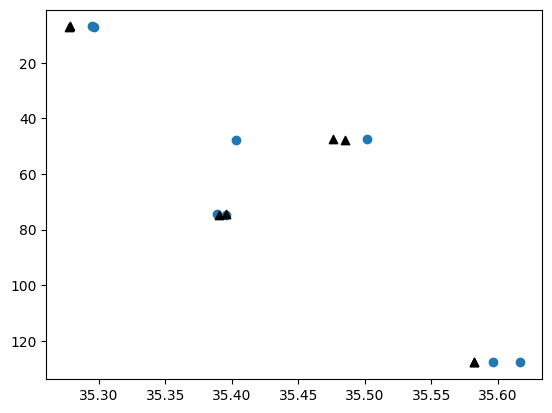

In [28]:
# Plot salinity data from discrete samples
plt.scatter(filtered_df["Discrete_Salinity"], filtered_df["CTD_Depth"])
ax = plt.gca()
ax.invert_yaxis()
plt.scatter(filtered_df["CTD_Salinity_1"], filtered_df["CTD_Depth"], c="k", marker="^")

In [29]:
filtered_df["Discrete_Salinity"].values

array([35.5967, 35.6163, 35.389 , 35.3953, 35.4034, 35.5018, 35.2952,
       35.2966])

In [30]:
filtered_df["CTD_Salinity_1"].values

array([35.5823, 35.5822, 35.3958, 35.3905, 35.4853, 35.4764, 35.2781,
       35.2773])

In [31]:
filtered_df["CTD_Salinity_2"].values

array([35.5812, 35.5812, 35.3981, 35.3861, 35.4821, 35.4836, 35.277 ,
       35.2767])

In [32]:
filtered_df["Discrete_Nitrate"].values

array([9.643,   nan, 9.293, 6.757, 0.048,   nan,   nan,   nan])

In [33]:
filtered_df["CTD_Oxygen"].values

array([3.4962, 3.4953, 3.7798, 3.7778, 4.6584, 4.6584, 4.8219, 4.8234])

In [34]:
filtered_df["Discrete_Oxygen"].values

array([3.732, 4.081, 4.028, 4.988, 4.97 , 5.203, 5.167,   nan])

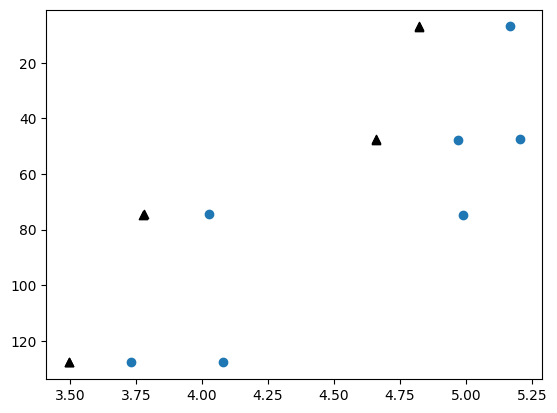

In [35]:
# Plot oxygen data from discrete samples
plt.scatter(filtered_df["Discrete_Oxygen"], filtered_df["CTD_Depth"])
ax = plt.gca()
ax.invert_yaxis()
plt.scatter(filtered_df["CTD_Oxygen"], filtered_df["CTD_Depth"], c="k", marker="^")